Written by Mary Letey, March 2026 with help from GPT

**NOTE!** This code's data generation process is specifically written for the exponential kernel case, because there sampling reduces to an AR(1) process which allows us to avoid computing sqrt(K), which can be expensive for large $\ell$. Should one wish to change the kernel here, the function `simulate_sufficient_stats_finite_k` would need to be rewritten.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import random, lax
from jax.scipy.sparse.linalg import cg
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

## **Data simulations**

In [14]:
# -----------------------
# Kernel construction + stats
# -----------------------
def kernel_exp(l, corr_len):
    idx = jnp.arange(l + 1, dtype=jnp.float32)
    K = jnp.where(
        corr_len == 0.0,
        jnp.eye(l + 1, dtype=jnp.float32),
        jnp.exp(-jnp.abs(idx[:, None] - idx[None, :]) / corr_len).astype(jnp.float32),
    )
    return K

def icl_kernel_stats(K):
    k = K[:-1, -1]            # (l,)
    Ksub = K[:-1, :-1]        # (l,l)
    k0 = k @ k
    k1 = k @ (Ksub @ k)
    l_ = Ksub.shape[0]
    tk  = (1.0 / l_) * jnp.trace(Ksub)
    tk2 = (1.0 / l_) * jnp.trace(Ksub @ Ksub)
    return k0, k1, tk, tk2

# -----------------------
# AR(1) sampling for exponential kernel
# -----------------------
def simulate_sufficient_stats_finite_k(key, n, d, l, rho, C, corr_len, k_tasks, old_w_set=None):
    key_wset, key_widx, key_scan = random.split(key, 3)
    L = l + 1

    dtype = C.dtype
    rho = jnp.asarray(rho, dtype=dtype)
    corr_len = jnp.asarray(corr_len, dtype=dtype)

    # Task bank
    sqrtC = jnp.linalg.cholesky(C + jnp.asarray(1e-12, dtype) * jnp.eye(d, dtype=dtype))
    if old_w_set==None:
        w_set = random.normal(key_wset, (k_tasks, d), dtype=dtype) @ sqrtC.T
    else:
        w_set = old_w_set
    w_idx = random.randint(key_widx, (n,), 0, k_tasks)
    w = w_set[w_idx]  # (n,d)

    # AR(1) params for exp kernel
    phi = jnp.where(
        corr_len == jnp.asarray(0, dtype),
        jnp.asarray(0, dtype),
        jnp.exp(-jnp.asarray(1, dtype) / corr_len),
    )
    sigma = jnp.sqrt(jnp.maximum(jnp.asarray(1, dtype) - phi * phi, jnp.asarray(0, dtype)))
    inv_sqrt_d = jnp.asarray(1, dtype) / jnp.sqrt(jnp.asarray(d, dtype))

    # t = 0 draw
    key_scan, kx0, ke0 = random.split(key_scan, 3)
    z0 = random.normal(kx0, (n, d), dtype=dtype)
    e0 = random.normal(ke0, (n,), dtype=dtype) * jnp.sqrt(rho)

    x0 = z0 * inv_sqrt_d
    y0 = jnp.sum(x0 * w, axis=1) + e0

    # initialize sums over t < l (includes t=0 if l>0)
    y_sum_x0 = y0[:, None] * x0
    y_sum_y0 = y0 * y0

    # If l==0, we should NOT include t=0 in training sums.
    y_sum_x = lax.cond(l > 0,
                       lambda _: y_sum_x0,
                       lambda _: jnp.zeros((n, d), dtype=dtype),
                       operand=None)
    y_sum_y = lax.cond(l > 0,
                       lambda _: y_sum_y0,
                       lambda _: jnp.zeros((n,), dtype=dtype),
                       operand=None)

    def step(carry, t):
        key_t, x_prev, y_sum_x, y_sum_y, y_last = carry

        key_t, kx, ke = random.split(key_t, 3)
        z_t = random.normal(kx, (n, d), dtype=dtype)
        e_t = random.normal(ke, (n,), dtype=dtype) * jnp.sqrt(rho)

        # ✅ Correct AR(1) scaling: only innovation has 1/sqrt(d)
        x_t = phi * x_prev + sigma * z_t * inv_sqrt_d
        y_t = jnp.sum(x_t * w, axis=1) + e_t

        def accum_fn(args):
            y_sum_x, y_sum_y = args
            y_sum_x = y_sum_x + y_t[:, None] * x_t
            y_sum_y = y_sum_y + y_t * y_t
            return (y_sum_x, y_sum_y)

        # accumulate for training times t < l
        y_sum_x, y_sum_y = lax.cond(t < l, accum_fn, lambda a: a, (y_sum_x, y_sum_y))

        return (key_t, x_t, y_sum_x, y_sum_y, y_t), None  # keep only last y in carry

    # scan t = 1..L-1, last step yields x_l and y_l in carry
    init = (key_scan, x0, y_sum_x, y_sum_y, y0)
    (key_end, x_last, y_sum_x, y_sum_y, y_last), _ = lax.scan(step, init, jnp.arange(1, L))

    return x_last, y_sum_x, y_sum_y, y_last, w_set

def simulate_sufficient_stats_INDEPENDENT_QUERY(key, n, d, l, rho, C, corr_len, k_tasks, old_w_set=None):
    key_wset, key_widx, key_scan, key_query = random.split(key, 4)
    L = l + 1

    dtype = C.dtype
    rho = jnp.asarray(rho, dtype=dtype)
    corr_len = jnp.asarray(corr_len, dtype=dtype)

    # Task bank
    sqrtC = jnp.linalg.cholesky(C + jnp.asarray(1e-12, dtype) * jnp.eye(d, dtype=dtype))
    if old_w_set == None:
        w_set = random.normal(key_wset, (k_tasks, d), dtype=dtype) @ sqrtC.T
    else:
        w_set = old_w_set
    w_idx = random.randint(key_widx, (n,), 0, k_tasks)
    w = w_set[w_idx]  # (n,d)

    # AR(1) params for exp kernel
    phi = jnp.where(
        corr_len == jnp.asarray(0, dtype),
        jnp.asarray(0, dtype),
        jnp.exp(-jnp.asarray(1, dtype) / corr_len),
    )
    sigma = jnp.sqrt(jnp.maximum(jnp.asarray(1, dtype) - phi * phi, jnp.asarray(0, dtype)))
    inv_sqrt_d = jnp.asarray(1, dtype) / jnp.sqrt(jnp.asarray(d, dtype))

    # t = 0 draw
    key_scan, kx0, ke0 = random.split(key_scan, 3)
    z0 = random.normal(kx0, (n, d), dtype=dtype)
    e0 = random.normal(ke0, (n,), dtype=dtype) * jnp.sqrt(rho)

    x0 = z0 * inv_sqrt_d
    y0 = jnp.sum(x0 * w, axis=1) + e0

    # initialize sums over t < l (includes t=0 if l>0)
    y_sum_x0 = y0[:, None] * x0
    y_sum_y0 = y0 * y0

    # If l==0, do NOT include t=0 in training sums
    y_sum_x = lax.cond(
        l > 0,
        lambda _: y_sum_x0,
        lambda _: jnp.zeros((n, d), dtype=dtype),
        operand=None,
    )
    y_sum_y = lax.cond(
        l > 0,
        lambda _: y_sum_y0,
        lambda _: jnp.zeros((n,), dtype=dtype),
        operand=None,
    )

    def step(carry, t):
        key_t, x_prev, y_sum_x, y_sum_y = carry

        key_t, kx, ke = random.split(key_t, 3)
        z_t = random.normal(kx, (n, d), dtype=dtype)
        e_t = random.normal(ke, (n,), dtype=dtype) * jnp.sqrt(rho)

        # Correlated AR(1) training sample
        x_t = phi * x_prev + sigma * z_t * inv_sqrt_d
        y_t = jnp.sum(x_t * w, axis=1) + e_t

        def accum_fn(args):
            y_sum_x, y_sum_y = args
            y_sum_x = y_sum_x + y_t[:, None] * x_t
            y_sum_y = y_sum_y + y_t * y_t
            return y_sum_x, y_sum_y

        # accumulate only for training times t < l
        y_sum_x, y_sum_y = lax.cond(t < l, accum_fn, lambda a: a, (y_sum_x, y_sum_y))

        return (key_t, x_t, y_sum_x, y_sum_y), None

    # Run correlated process only up to time l-1
    # For l=0 or l=1 this scan is empty, which is fine.
    init = (key_scan, x0, y_sum_x, y_sum_y)
    (_, _, y_sum_x, y_sum_y), _ = lax.scan(step, init, jnp.arange(1, l))

    # Independent query sample x_l with same marginal covariance I/d
    key_query, kx_last, ke_last = random.split(key_query, 3)
    z_last = random.normal(kx_last, (n, d), dtype=dtype)
    e_last = random.normal(ke_last, (n,), dtype=dtype) * jnp.sqrt(rho)

    x_last = z_last * inv_sqrt_d
    y_last = jnp.sum(x_last * w, axis=1) + e_last

    return x_last, y_sum_x, y_sum_y, y_last, w_set
    
# -----------------------
# Matrix-free H and H^T operators
# -----------------------
def Hv(v_mat, x_l, y_sum_x, y_sum_y, d, l):
    vA = v_mat[:, :d]     # (d,d)
    v_last = v_mat[:, d]  # (d,)

    tmp = y_sum_x @ vA.T
    term1 = (d / l) * jnp.sum(x_l * tmp, axis=1)
    term2 = (1.0 / l) * y_sum_y * (x_l @ v_last)
    return term1 + term2

def HTu(u, x_l, y_sum_x, y_sum_y, d, l):
    Xu = x_l * u[:, None]
    A = (d / l) * (Xu.T @ y_sum_x)
    b = (1.0 / l) * (x_l.T @ (u * y_sum_y))
    return jnp.concatenate([A, b[:, None]], axis=1)

# -----------------------
# ICL trace formula
# -----------------------
# THIS IS ONE OF THE TRACE FORMULAS, WHICH ASSUMES THAT
# k0, k1, k2 are all O(1) wrt ell. 
# THIS IS THE FORMULA GIVEN BY LEMMA 1 IN APPENDIX C OF THE TEXT.
def ICL_trace_from_Gamma(Gamma, d, l, rho, C_test, k0, k1, tk, tk2, alpha):
    tc = (1.0 / d) * jnp.trace(C_test)
    rho1 = rho + tk * tc
    rho2 = tk * rho + tk2 * tc

    A_left = tk * C_test + (d / l) * k0 * tc * jnp.eye(d, dtype=jnp.float32)
    B_tl   = (tk * tk) * C_test + rho2 * (d / l) * jnp.eye(d, dtype=jnp.float32)
    B_br   = rho1 * rho1

    Gamma_sq = Gamma[:, :d]
    tr_gamma_sigma = (1.0 / d) * jnp.trace(Gamma_sq)
    tr_gamma_sigmaCsigma = (1.0 / d) * jnp.trace(Gamma_sq @ C_test)

    tensor_term = (1.0 / (alpha * alpha)) * (k1 * tc + k0 * rho) * (tr_gamma_sigma ** 2) \
                  + (2.0 / alpha) * k0 * tk * tr_gamma_sigma * tr_gamma_sigmaCsigma

    tr_GA = jnp.trace(Gamma_sq @ A_left.T)

    last_col = Gamma[:, d]
    tr_GBG = jnp.trace(Gamma_sq @ B_tl @ Gamma_sq.T) + B_br * (last_col @ last_col)

    return rho + tc - (2.0 / d) * tr_GA + (1.0 / d) * tr_GBG + tensor_term

# THIS IS THE OTHER TRACE FORMULA, WHICH ASSUMES THAT
# k0/ell, k1/ell^2, k2/ell are O(1) wrt ell. 
# THIS IS THE FORMULA GIVEN BY LEMMA 2 IN APPENDIX C OF THE TEXT.
def ICL_trace_from_Gamma_PROPORTIONAL(Gamma, d, l, rho, k0, k1, tk, tk2, alpha):
    k0_tilde = k0/l
    k1_tilde = k1/(l**2)
    k2_tilde = tk2/l
    
    Gamma_sq = Gamma[:, :d]

    return 1 + rho - 2*k0_tilde*jnp.trace(Gamma_sq) + k2_tilde*jnp.trace(Gamma_sq @ Gamma_sq.T) + k1_tilde*jnp.trace(Gamma_sq @ Gamma_sq) + k1_tilde*(jnp.trace(Gamma_sq)**2)

# -----------------------
# Per-sample predictor from Gamma
# -----------------------
# This computes the predictor
# yhat = <Gamma, H> 
# given some matrix Gamma and the x,y data need to compute H.
def predict_from_Gamma(Gamma, x_l, y_sum_x, y_sum_y, d, l):
    Gamma_A = Gamma[:, :d]   # (d,d)
    Gamma_b = Gamma[:, d]    # (d,)

    # First block contribution:
    term1 = (d / l) * jnp.sum((x_l @ Gamma_A) * y_sum_x, axis=1)
    # Last column contribution:
    term2 = (1.0 / l) * y_sum_y * (x_l @ Gamma_b)

    return term1 + term2

# -----------------------
# Direct Monte Carlo MSE from fresh sampled data
# -----------------------
# This function simulates the test population averaging of the MSE loss
# E_test [ (y - yhat)^2 ] using n_eval samples
def mse_from_data(key, Gamma, n_eval, d, l, rho, C, corr_len):
    x_l, y_sum_x, y_sum_y, y_last, _ = simulate_sufficient_stats_finite_k(key, n_eval, d, l, rho, C, corr_len, 2*n_eval)
    y_hat = predict_from_Gamma(Gamma, x_l, y_sum_x, y_sum_y, d, l)
    mse = jnp.mean((y_hat - y_last) ** 2)
    return mse, y_hat, y_last

# -----------------------
# Conjugate gradient solution for Gamma
# -----------------------
def gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg, cg_tol=1e-10, cg_maxiter=5000):

    p = d * (d + 1)
    reg = (n / d) * lambdareg

    def matvec(v_flat):
        v_mat = v_flat.reshape(d, d + 1)
        hv = Hv(v_mat, x_l, y_sum_x, y_sum_y, d, l)
        ht_h_v = HTu(hv, x_l, y_sum_x, y_sum_y, d, l)
        return (reg * v_mat + ht_h_v).reshape(p)

    b_mat = HTu(y_last, x_l, y_sum_x, y_sum_y, d, l)
    b = b_mat.reshape(p)

    gamma, _ = cg(matvec, b, tol=cg_tol, maxiter=cg_maxiter)

    # report residual
    r = b - matvec(gamma)
    rel_res = jnp.linalg.norm(r) / (jnp.linalg.norm(b) + 1e-30)

    return gamma.reshape(d, d + 1), rel_res
    
# -----------------------
# One pass over Gamma error
# -----------------------
def one_replicate(key, n, d, l, rho, C, C_test, corr_len, lambdareg, alpha, k_tasks, cg_tol, cg_maxiter):
    K = kernel_exp(l, corr_len)
    k0, k1, tk, tk2 = icl_kernel_stats(K)

    x_l, y_sum_x, y_sum_y, y_last, _ = simulate_sufficient_stats_finite_k(key, n, d, l, rho, C, corr_len, k_tasks)

    Gamma, _ = gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg, cg_tol, cg_maxiter)

    error_data, _, _ = mse_from_data(5*key,Gamma,n_eval=2*n,d=d,l=l,rho=rho,C=C_test,corr_len=corr_len)
    error_trace_const = ICL_trace_from_Gamma(Gamma, d, l, jnp.asarray(rho, jnp.float32), C_test, k0, k1, tk, tk2, jnp.asarray(alpha, jnp.float32))
    error_trace_prop = ICL_trace_from_Gamma_PROPORTIONAL(Gamma, d, l, jnp.asarray(rho, jnp.float32), k0, k1, tk, tk2, jnp.asarray(alpha, jnp.float32))
    
    return error_data, error_trace_const, error_trace_prop
# -----------------------
# Multiple passes to average over Gamma error
# -----------------------
@partial(jax.jit, static_argnames=("numavg", "n", "d", "l", "k_tasks", "cg_maxiter"))
def avg_over_replicates(
    base_key, numavg, n, d, l, rho, C, C_test, corr_len,
    lambdareg, alpha, k_tasks, cg_tol=1e-4, cg_maxiter=200
):
    keys = random.split(base_key, numavg)

    dtype = C.dtype
    init = (
        jnp.asarray(0, dtype=jnp.int32),         # count
        jnp.zeros((3,), dtype=dtype),            # mean: [mean_x, mean_y]
        jnp.zeros((3,), dtype=dtype),            # M2:   [M2_x, M2_y]
    )

    def body(state, k):
        count, mean, M2 = state

        x, y, z = one_replicate(
            k, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, cg_tol, cg_maxiter)

        vals = jnp.stack([x, y, z])  

        count_new = count + 1
        delta = vals - mean
        mean_new = mean + delta / count_new
        delta2 = vals - mean_new
        M2_new = M2 + delta * delta2

        return (count_new, mean_new, M2_new), vals

    (count, mean, M2), errs = lax.scan(body, init, keys)

    var = jnp.where(
        count > 1,
        M2 / (count - 1),
        jnp.zeros((3,), dtype=dtype)
    )
    std = jnp.sqrt(var)

    return mean, std, errs

# -----------------------
# Sweeping functions 
# -----------------------
def run_sweep_over_corr_lens(lens, seed=0, d=32, tau=0.5, alpha=1.0, kappa=1.0,
              rho=0.01, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200):
    l = int(alpha * d)
    n = int(tau * d * d)
    k_tasks = int(kappa * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for corr_len in list(lens):
        key, subkey = random.split(key)
        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, cg_tol, cg_maxiter)
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

def run_sweep_over_taus(taus, seed=0, d=32, alpha=1.0, kappa=1.0,
              rho=0.01, corr_len=0.0, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200):
    l = int(alpha * d)
    k_tasks = int(kappa * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for tau in list(taus):
        key, subkey = random.split(key)
        n = int(tau * d * d)
        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, cg_tol, cg_maxiter
        )
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

def run_sweep_over_alphas(alphas, lens, seed=0, d=32, tau=0.5, kappa=1.0,
              rho=0.01, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200):
    n = int(tau * d * d)
    k_tasks = int(kappa * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for i in range(len(alphas)):
        
        key, subkey = random.split(key)
        l = int(alphas[i] * d)
        corr_len = lens[i]

        print(f"tau is {tau}")
        print(f"kappa is {kappa}")
        print(f"beta is {corr_len/l}")
        print(f"alpha is {alphas[i]}")

        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alphas[i], k_tasks, cg_tol, cg_maxiter)
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

def run_sweep_over_kappas(kappas, seed=0, d=32, tau=0.5, alpha=1.0,
              rho=0.01, corr_len=0.0, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200):
    l = int(alpha * d)
    n = int(tau * d * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for kappa in list(kappas):
        key, subkey = random.split(key)
        k_tasks = int(kappa * d)
        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, cg_tol, cg_maxiter
        )
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

## **Transition between Constant and Proportional**

In [15]:
tau = 4.0
alpha = 1.0
kappa = 0.5
rho = 0.01
numavg = 20
lambdareg = 1e-8

deez = [16]

means = {}
sts = {}
lens = {}

for d in deez:
    l = int(alpha*d)
    mults = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0, 20.0, 50.0, 100.0]
    mylen = [0, 1, 2, 4, 6, 8, 10] + [l*mult for mult in mults]
    lens[d] = np.sort(np.array(mylen))
    means[d], sts[d] = run_sweep_over_corr_lens(lens[d], seed=0, d=d, tau=tau, alpha=alpha, kappa=kappa,
                rho=rho, numavg=numavg, lambdareg=lambdareg,
                cg_tol=1e-8, cg_maxiter=2000) 
    print(f"{d} is done")

16 is done


Text(0, 0.5, 'ICL Error')

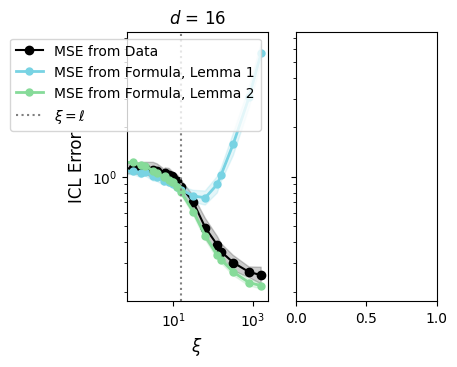

In [17]:
length=4*len(deez)
fig, axes = plt.subplots(1, len(deez)+1, figsize=(length, 3.5), sharey=True)

colors = [
    "black",  # rich blue (added)
    "#78D3E3",  # teal
    "#86DB99",  # soft green
]

for i, d in enumerate(deez):
    axes[i].plot(lens[d], means[d][:,0], marker='o', label='MSE from Data ', color=colors[0])#, lw=3, ms=9) 
    axes[i].fill_between(lens[d], np.array(means[d][:,0])-np.array(sts[d][:,0]), np.array(means[d][:,0])+np.array(sts[d][:,0]), alpha=0.2, color=colors[0])
    axes[i].plot(lens[d], means[d][:,1], marker='o', label='MSE from Formula, Lemma 1', color=colors[1], lw=2, ms=5) 
    axes[i].fill_between(lens[d], np.array(means[d][:,1])-np.array(sts[d][:,1]), np.array(means[d][:,1])+np.array(sts[d][:,1]), alpha=0.2, color=colors[1]) 
    axes[i].plot(lens[d], means[d][:,2], marker='o', label='MSE from Formula, Lemma 2', color=colors[2], lw=2, ms=5) 
    axes[i].fill_between(lens[d], np.array(means[d][:,2])-np.array(sts[d][:,2]), np.array(means[d][:,2])+np.array(sts[d][:,2]), alpha=0.2, color=colors[2]) 
    
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(rf'$d$ = {d}', fontsize=12) #, $\alpha$ = {alpha}, $\tau$ = {tau}, $\kappa$ = {kappa}')
    axes[i].set_xlabel(r'$\xi$', fontsize=12)
    
    axes[i].axvline(int(alpha*d), linestyle=':', color='gray', label=r'$\xi = \ell$')

axes[0].legend()
axes[0].set_ylabel('ICL Error', fontsize=12)